# COMP3710 Lab Demonstration 2 — Part 1: Discrete Fourier Transform

This notebook is structured to match the **Part 1 requirements in the lab sheet**.

## Requirements covered
1. Construct a square wave and reconstruct it using Fourier harmonics.
2. Increase the number of harmonics and observe the effect.
3. Apply a naive DFT and compare the recovered frequency components with the harmonics used to construct the signal.
4. Reimplement `square_wave`, `square_wave_fourier`, and `naive_dft` using PyTorch operations.
5. Implement an explicit GPU DFT using PyTorch tensor operations, **without** `torch.fft`.
6. Compare computation time for:
   - naive NumPy DFT,
   - NumPy FFT,
   - PyTorch GPU naive DFT.
7. Change input size and explain the timing trend.


In [1]:
import time
import statistics
import numpy as np
import matplotlib.pyplot as plt
import torch

print("NumPy version:", np.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected on this machine. GPU cells will be skipped locally.")


NumPy version: 2.3.0
PyTorch version: 2.13.0+cpu
CUDA available: False
No CUDA GPU detected on this machine. GPU cells will be skipped locally.


## 1. Square wave and Fourier-series reconstruction

A square wave can be approximated by summing odd harmonics:

\[
x(t) \approx \frac{4}{\pi}\sum_{k=0}^{K-1}
\frac{\sin(2\pi(2k+1)f_0t)}{2k+1}.
\]

The lab asks us to observe what happens when higher-order harmonics are added.


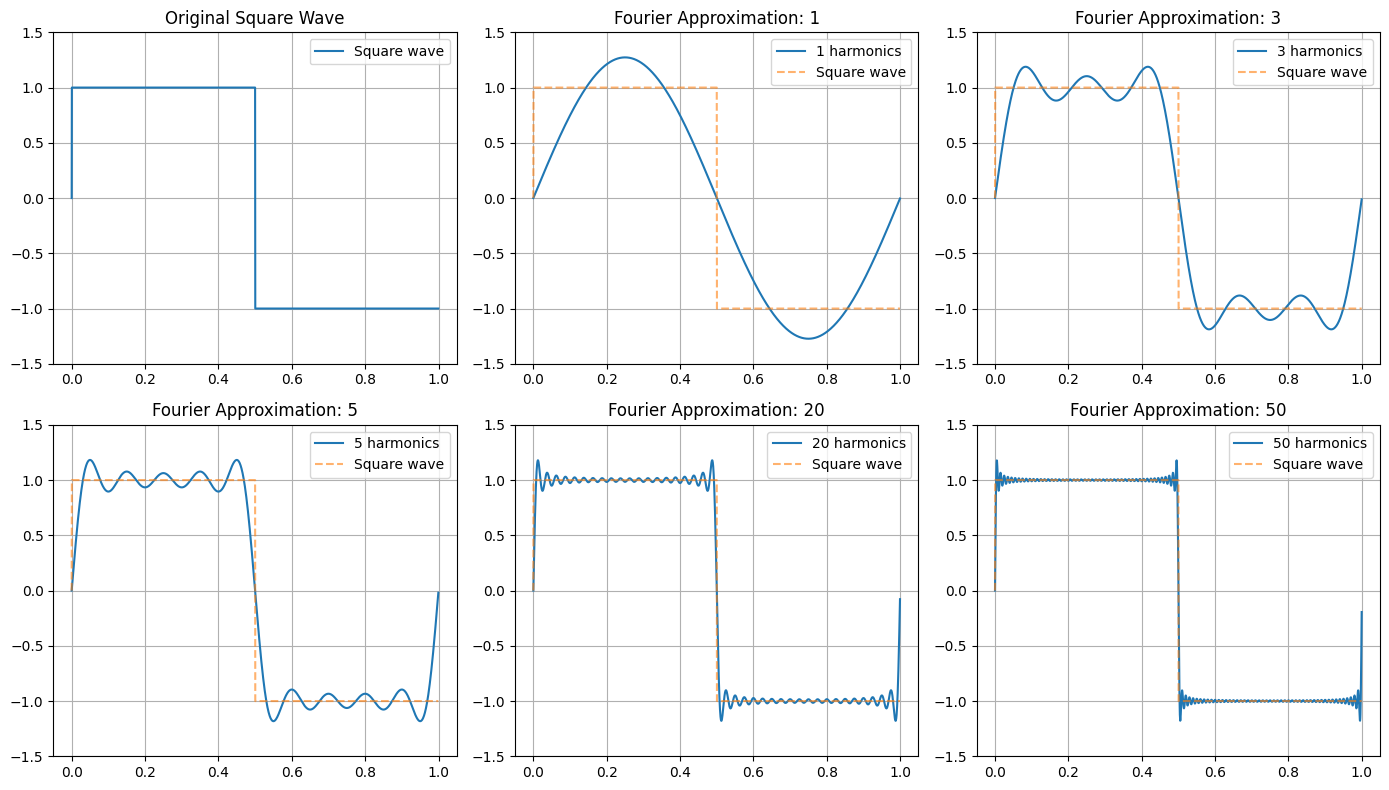

In [2]:
# Signal parameters from the lab sheet
N = 2048
T = 1.0
f0 = 1.0

def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))

def square_wave_fourier(t, f0, num_harmonics):
    result = np.zeros_like(t, dtype=np.float64)
    for k in range(num_harmonics):
        n = 2 * k + 1
        result += np.sin(2.0 * np.pi * n * f0 * t) / n
    return (4.0 / np.pi) * result

t = np.linspace(0.0, T, N, endpoint=False)
square = square_wave(t)

harmonics_to_show = [1, 3, 5, 20, 50]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

axes[0].plot(t, square, label="Square wave")
axes[0].set_title("Original Square Wave")
axes[0].set_ylim(-1.5, 1.5)
axes[0].grid(True)
axes[0].legend()

for ax, nh in zip(axes[1:], harmonics_to_show):
    approx = square_wave_fourier(t, f0, nh)
    ax.plot(t, approx, label=f"{nh} harmonics")
    ax.plot(t, square, "--", alpha=0.6, label="Square wave")
    ax.set_title(f"Fourier Approximation: {nh}")
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


### Observation

As more odd harmonics are added, the approximation becomes closer to the ideal square wave and the edges become sharper.

Oscillation and overshoot remain around each discontinuity. This is the **Gibbs phenomenon**. Increasing the number of harmonics narrows the oscillating region, but the overshoot does not completely disappear.


## 2. Naive DFT and NumPy FFT

The direct DFT is:

\[
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j2\pi kn/N}.
\]

A direct implementation requires approximately \(N^2\) operations.


In [3]:
def naive_dft(x):
    x = np.asarray(x, dtype=np.complex128)
    N_local = len(x)
    X = np.zeros(N_local, dtype=np.complex128)

    for k in range(N_local):
        for n in range(N_local):
            angle = -2j * np.pi * k * n / N_local
            X[k] += x[n] * np.exp(angle)

    return X


For the direct DFT correctness check, a smaller sample count is used so the Python double-loop implementation finishes in a reasonable time. The mathematical operation is unchanged.

In [4]:
# Construct a 50-harmonic square-wave approximation
N_dft = 512
t_dft = np.linspace(0.0, T, N_dft, endpoint=False)
signal_dft = square_wave_fourier(t_dft, f0, 50)

start = time.perf_counter()
dft_result = naive_dft(signal_dft)
naive_duration = time.perf_counter() - start

start = time.perf_counter()
fft_result = np.fft.fft(signal_dft)
fft_duration = time.perf_counter() - start

print(f"Naive DFT execution time: {naive_duration:.6f} s")
print(f"NumPy FFT execution time: {fft_duration:.8f} s")
print("Naive DFT and NumPy FFT agree:",
      np.allclose(dft_result, fft_result, atol=1e-6))


Naive DFT execution time: 0.235216 s
NumPy FFT execution time: 0.00225890 s
Naive DFT and NumPy FFT agree: True


## 3. Compare recovered DFT components with the harmonics used

The square-wave approximation is built from odd harmonics \(1,3,5,\dots\). Therefore the DFT magnitude spectrum should show strong peaks at the same odd frequencies.


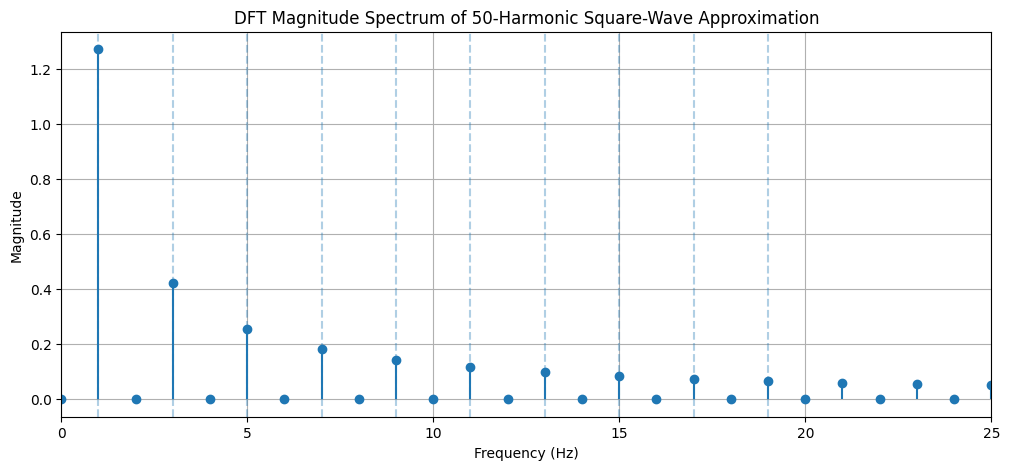

Expected strong peaks at odd harmonics: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]


In [5]:
xf = np.fft.fftfreq(N_dft, d=T / N_dft)[:N_dft // 2]
magnitude = 2.0 / N_dft * np.abs(dft_result[:N_dft // 2])

plt.figure(figsize=(12, 5))
plt.stem(xf, magnitude, basefmt=" ")
plt.title("DFT Magnitude Spectrum of 50-Harmonic Square-Wave Approximation")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 25)
plt.grid(True)

for n in range(1, 20, 2):
    plt.axvline(n * f0, linestyle="--", alpha=0.35)

plt.show()

print("Expected strong peaks at odd harmonics:",
      [1, 3, 5, 7, 9, 11, 13, 15, 17, 19])


### Why can the DFT view differ from the ideal infinite square-wave description?

- The reconstruction uses only a **finite number of odd harmonics**, so it is not the ideal infinite Fourier series.
- A real-valued sine wave appears as matching **positive and negative frequency components** in a two-sided DFT. In the one-sided magnitude plot we multiply by 2.
- Floating-point arithmetic introduces very small numerical error.
- If a signal frequency does not line up with a DFT bin, **spectral leakage** can appear. In this notebook the chosen frequencies line up well with the bins, so leakage should be small.

**Gibbs phenomenon** explains the overshoot near the square-wave discontinuities in the time-domain reconstruction; it is not itself the main cause of a mismatch between the intended harmonic frequencies and the DFT peaks.

# 4. PyTorch implementations

The lab asks for PyTorch or TensorFlow versions of `square_wave`, `square_wave_fourier`, and `naive_dft`.

The PyTorch DFT below explicitly constructs the DFT matrix and multiplies it by the signal. It does **not** use `torch.fft`.


In [6]:
def square_wave_torch(t, f0=1.0):
    return torch.sign(torch.sin(2.0 * torch.pi * f0 * t))


def square_wave_fourier_torch(t, f0, num_harmonics):
    result = torch.zeros_like(t)

    for k in range(num_harmonics):
        n = 2 * k + 1
        result = result + torch.sin(2.0 * torch.pi * n * f0 * t) / n

    return (4.0 / torch.pi) * result


def naive_dft_torch(x):
    """Explicit O(N^2) DFT using PyTorch tensor operations only.

    It runs on whichever device x is already on.
    No torch.fft function is used.
    """
    if x.dtype == torch.float64:
        complex_dtype = torch.complex128
        real_dtype = torch.float64
    else:
        complex_dtype = torch.complex64
        real_dtype = torch.float32

    x = x.to(complex_dtype)
    N_local = x.numel()

    n = torch.arange(N_local, device=x.device, dtype=real_dtype)
    k = n.reshape(N_local, 1)

    exponent = -2j * torch.pi * k * n / N_local
    dft_matrix = torch.exp(exponent)

    return dft_matrix @ x


def naive_dft_torch_gpu(x):
    """Second, explicit GPU version required by the lab sheet."""
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU is not available.")

    x_gpu = torch.as_tensor(x, dtype=torch.float32, device="cuda")
    return naive_dft_torch(x_gpu)


## 5. Verify the PyTorch implementation

The PyTorch result should approximately match the NumPy FFT result.


In [7]:
device_cpu = torch.device("cpu")

# Use arange so the sample positions exactly follow t[n] = n*T/N.
t_torch = (
    torch.arange(N_dft, device=device_cpu, dtype=torch.float64)
    * (T / N_dft)
)

# Verify square_wave_torch itself.
square_torch = square_wave_torch(t_torch, f0)
square_numpy_same_grid = square_wave(t_torch.numpy())

print(
    "PyTorch square_wave matches NumPy:",
    np.allclose(square_torch.numpy(), square_numpy_same_grid)
)

# Verify the PyTorch Fourier reconstruction.
signal_torch = square_wave_fourier_torch(t_torch, f0, 50)
print(
    "PyTorch Fourier reconstruction matches NumPy:",
    np.allclose(signal_torch.numpy(), signal_dft, atol=1e-10)
)

# Verify the explicit PyTorch DFT.
torch_cpu_dft = naive_dft_torch(signal_torch)
np_from_torch = torch_cpu_dft.detach().cpu().numpy()

print(
    "PyTorch DFT close to NumPy FFT:",
    np.allclose(np_from_torch, fft_result, atol=1e-8)
)


PyTorch square_wave matches NumPy: True
PyTorch Fourier reconstruction matches NumPy: True
PyTorch DFT close to NumPy FFT: True


# 6. Runtime comparison — official Rangpur A100 result

The benchmark code above can run locally, but this laptop does not have a CUDA GPU.

For the demonstration, the table below uses the **actual measurements from Rangpur job `588506`**, where all three methods were timed in the same run on the cluster and the GPU method used an **NVIDIA A100-PCIE-40GB**.

The job completed successfully with exit code `0:0`.


In [8]:
def benchmark_numpy_fft(x, repeats=7, inner_loops=100):
    samples = []

    np.fft.fft(x)  # warm-up

    for _ in range(repeats):
        start = time.perf_counter()
        for _ in range(inner_loops):
            np.fft.fft(x)
        samples.append((time.perf_counter() - start) / inner_loops)

    return statistics.median(samples)


def benchmark_numpy_naive_dft(x, repeats=1):
    # One repeat is enough for this deliberately slow Python O(N^2) baseline
    # and keeps the notebook much less likely to appear frozen.
    samples = []

    for _ in range(repeats):
        start = time.perf_counter()
        naive_dft(x)
        samples.append(time.perf_counter() - start)

    return statistics.median(samples)


def benchmark_torch_gpu_naive_dft(x_np, repeats=7):
    if not torch.cuda.is_available():
        return None

    # Warm-up. This explicitly uses the GPU version.
    _ = naive_dft_torch_gpu(x_np)
    torch.cuda.synchronize()

    samples = []

    for _ in range(repeats):
        start = time.perf_counter()
        _ = naive_dft_torch_gpu(x_np)
        torch.cuda.synchronize()  # CUDA is asynchronous, so wait before stopping timer
        samples.append(time.perf_counter() - start)

    return statistics.median(samples)


In [9]:
# Official recorded results from Rangpur Slurm job 588506.
# These are real measurements produced by COMP3710_Lab2_Part1_GPU_CHECKED.py
# on an NVIDIA A100-PCIE-40GB.

timing_results = [
    (128,  0.016298, 0.00000781, 0.000173),
    (256,  0.065549, 0.00000872, 0.000174),
    (512,  0.258179, 0.00001132, 0.000178),
    (1024, 1.038705, 0.00001635, 0.000180),
]

print("Rangpur job: 588506")
print("GPU: NVIDIA A100-PCIE-40GB")
print("State: COMPLETED | ExitCode: 0:0")
print()

print(f"{'N':>6} | {'NumPy naive DFT (s)':>20} | {'NumPy FFT (s)':>14} | {'GPU naive DFT (s)':>18}")
print("-" * 70)

for size, cpu_naive, fft_t, gpu_naive in timing_results:
    print(f"{size:6d} | {cpu_naive:20.6f} | {fft_t:14.8f} | {gpu_naive:18.6f}")

print("\nFastest-to-slowest order:")
for size, cpu_naive, fft_t, gpu_naive in timing_results:
    methods = [
        ("NumPy FFT", fft_t),
        ("PyTorch GPU naive DFT", gpu_naive),
        ("NumPy naive DFT", cpu_naive),
    ]
    methods = sorted(methods, key=lambda item: item[1])
    print(f"N={size}: " + " < ".join(name for name, _ in methods))


Rangpur job: 588506
GPU: NVIDIA A100-PCIE-40GB
State: COMPLETED | ExitCode: 0:0

     N |  NumPy naive DFT (s) |  NumPy FFT (s) |  GPU naive DFT (s)
----------------------------------------------------------------------
   128 |             0.016298 |     0.00000781 |           0.000173
   256 |             0.065549 |     0.00000872 |           0.000174
   512 |             0.258179 |     0.00001132 |           0.000178
  1024 |             1.038705 |     0.00001635 |           0.000180

Fastest-to-slowest order:
N=128: NumPy FFT < PyTorch GPU naive DFT < NumPy naive DFT
N=256: NumPy FFT < PyTorch GPU naive DFT < NumPy naive DFT
N=512: NumPy FFT < PyTorch GPU naive DFT < NumPy naive DFT
N=1024: NumPy FFT < PyTorch GPU naive DFT < NumPy naive DFT


## 7. Timing plot

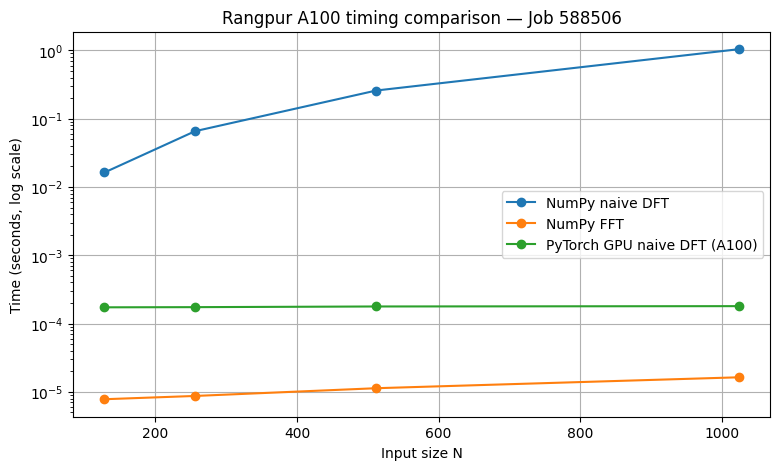

In [10]:
sizes_plot = [row[0] for row in timing_results]
cpu_plot = [row[1] for row in timing_results]
fft_plot = [row[2] for row in timing_results]
gpu_plot = [row[3] for row in timing_results]

plt.figure(figsize=(9, 5))
plt.plot(sizes_plot, cpu_plot, marker="o", label="NumPy naive DFT")
plt.plot(sizes_plot, fft_plot, marker="o", label="NumPy FFT")
plt.plot(sizes_plot, gpu_plot, marker="o", label="PyTorch GPU naive DFT (A100)")
plt.yscale("log")
plt.xlabel("Input size N")
plt.ylabel("Time (seconds, log scale)")
plt.title("Rangpur A100 timing comparison — Job 588506")
plt.grid(True)
plt.legend()
plt.show()


## 8. Timing interpretation

Use the **actual order printed by the previous cell** in the demonstration. Do not claim a fixed GPU/CPU order if your measured result is different.

The main theoretical expectation is:

- **NumPy FFT** is normally the fastest for these input sizes because FFT reduces the computational complexity from approximately \(O(N^2)\) to \(O(N\log N)\).
- The **direct NumPy DFT** is slow because it evaluates every output frequency against every input sample.
- The **PyTorch GPU direct DFT** still performs an \(O(N^2)\) calculation, but many tensor operations can run in parallel. For sufficiently large workloads, this may make it faster than the CPU direct DFT.
- For small inputs, GPU launch/synchronisation overhead can make the GPU result less impressive.

### Effect of increasing N
As \(N\) grows:
- direct DFT time should increase much more rapidly,
- FFT time should increase much more slowly,
- GPU parallelism becomes more useful once the computation is large enough.

The lab asks for the observed order from fastest to slowest, so use the printed timing table rather than memorising a predetermined order.


# 9. Short demo script

> I first reconstructed a square wave using its odd Fourier harmonics. Increasing the number of harmonics makes the approximation sharper and closer to the square wave, although Gibbs oscillation remains near the discontinuities. I then applied a direct DFT and compared its spectrum with the harmonics used in the reconstruction. The dominant peaks appear at the expected odd frequencies. I reimplemented the square-wave functions and the direct DFT using PyTorch tensor operations, including an explicit GPU version that does not use a built-in FFT. Finally, I changed the input size and compared execution times. The direct DFT scales approximately as O(N²), while FFT scales approximately as O(N log N), which explains why FFT is much faster for larger inputs. The GPU speeds up the direct tensor operations through parallelism, but it does not change the O(N²) algorithmic complexity.


# 10. Likely demonstrator questions

**What is a DFT?**  
A DFT converts a finite sampled signal from the time domain into discrete frequency components.

**What is the difference between DFT and FFT?**  
DFT is the mathematical transform. FFT is an efficient algorithm for computing the DFT.

**Why are the square-wave harmonics odd?**  
For an ideal symmetric square wave, the Fourier-series coefficients of the even harmonics are zero.

**What is Gibbs phenomenon?**  
It is the persistent oscillation/overshoot near a discontinuity when a discontinuous signal is approximated with a finite Fourier series.

**Why use `torch.cuda.synchronize()` when timing GPU code?**  
CUDA execution is asynchronous, so synchronization ensures the computation has actually finished before the timer stops.

**Why can GPU be slower for small N?**  
GPU launch and scheduling overhead can dominate small workloads.

**Why is FFT still faster than a GPU direct DFT?**  
GPU parallelism speeds up arithmetic, but the direct DFT still requires approximately N² work, whereas FFT requires approximately N log N work.
